In [275]:
import sys
import os

sys.path.append(os.path.abspath('./predictability_emergence')) 

import DataMakar
import DataHolder
import buildmodel
import helpers

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

import torch.optim.lr_scheduler as lr_scheduler
import time

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import glob
import json
import pickle
from scipy.stats import percentileofscore
from statsmodels.stats.contingency_tables import mcnemar

from PIL import Image

import cartopy.crs as ccrs
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.size'] = 12
mpl.rcParams['font.sans-serif']=['Verdana']

params = {"ytick.color": "k",
          "xtick.color": "k",
          "axes.labelcolor": "k",
          "axes.edgecolor": "k"}
plt.rcParams.update(params)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [276]:
ssplist = ["370"]

ssplistplot = ["hist","370"] # thank god i haven't flipflopped on ssp labeling! that would be so annoying

# set user parameters

experiment_era = [1970,2100]
baselineera = [1900,1950]
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

experiment_era_obs = [1970,2025]
baselineera_obs = [1950,1980]

inputlength = 10
outputavgtime = 5
# data params
outres = 10
timerange = [1900,2100]
filefront = "MPI_"
modelfilefront = "MPI_recordtemp_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'
obstimerange = [1940,2025]
data_dir = 'data'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]

imp.reload(DataHolder)

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
    "obstimerange":obstimerange,
    "data_dir":data_dir
}

ntrain = 25
nval = 13
test = np.arange(38,50)

n_best = 3

#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)

latvec = AllData.output_lat
lonvec = AllData.output_lon

lonmesh,latmesh = np.meshgrid(lonvec+5,latvec+5)

device = 'mps'


data/MPI_annualmean_370_tos_1900-2100.pkl


In [277]:

imp.reload(DataHolder)
AllObs = DataHolder.ERA5InputOutput(params)

lenobs = experiment_era_obs[1]-experiment_era_obs[0]-outputavgtime-inputlength+1

In [278]:
latsel = 40
lonsel = 0

metricsout = "metrics/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(latsel)+"_lon_"+str(lonsel)+"_seed*.json"
filelist = glob.glob(metricsout)

bestseeds = helpers.get_best_files(filelist,n_best)
# obsinput,obsinputgmt,obsinputpriorrecord,obsoutput = AllObs.obs_histrecordmax_nochopend(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,latsel,lonsel)
obsinput,obsinputgmt,obsinputpriorrecord,obsoutput = AllObs.obs_recordmax_withrecordmax_nochopend(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,latsel,lonsel)

obsinput_t = torch.tensor(obsinput,dtype=torch.float32)
obsinputgmt_t = torch.tensor(obsinputgmt,dtype=torch.float32)
obsinputpriorrecord_t = torch.tensor(obsinputpriorrecord,dtype=torch.float32)
obsinputvectors_t = torch.cat((obsinputgmt_t,obsinputpriorrecord_t),axis=-1)

obsinput_climo_t = torch.ones(obsinput_t.size())*torch.mean(obsinput_t,axis=0,keepdims=True)

obspredall = np.empty((3,len(obsinputgmt)))

_, _, alltest = AllData.trainvaltest_histrecordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,latsel,lonsel)

MPIinputtest, MPIinputtestGMT, MPIoutputtest = DataHolder.tensortime_onehot_withrecordmax(alltest,nclasses=2)

MPIpredall = np.empty((3,12,47))

obspredclimo = np.empty((3,len(obsinputgmt)))

for iseed,seed in enumerate(bestseeds):
    # load the model

    loadfile = "models/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(latsel)+"_lon_"+str(lonsel)+"_seed_"+str(seed)+".pt"
    cnn = buildmodel.CNNclassifier(obsinput_t, obsinputvectors_t, 2).to('cpu')
    cnn.load_state_dict(torch.load(loadfile,map_location=torch.device('cpu'), weights_only=False))
    cnn.to(device)

    for imem in range(12):

        inds = np.arange(35*(imem),35*(imem+1))
        inds2 = 300+np.arange((imem)*79,(imem)*79+12)

        inds = np.concatenate((inds,inds2))

        MPISSTsub = MPIinputtest[inds]
        # inputobssub = obsinputvectors_t[10:47]
        inputobssub = obsinputvectors_t

        # nerfgmt = MPIinputtestGMT[inds,0]

        # inputobssub[:,0] = nerfgmt

        with torch.no_grad():
            cnn.eval()
            obspred = cnn(obsinput_t.to(device), obsinputvectors_t.to(device)).cpu().numpy()
            MPIpred = cnn(MPISSTsub.to(device), inputobssub.to(device)).cpu().numpy()
            climopred = cnn(obsinput_climo_t.to(device), obsinputvectors_t.to(device)).cpu().numpy()

        MPIpredall[iseed,imem] = MPIpred[:,1]
    obspredall[iseed] = obspred[:,1]
    obspredclimo[iseed] = climopred[:,1]

obspredavg = np.mean(obspredall,axis=0)
obspredclass = np.round(obspredavg)
MPIpredavg = np.mean(MPIpredall,axis=0)
climopredavg = np.mean(obspredclimo,axis=0)


baseline for temp records is 0 50 (not used)
indices of future period are 104 -4
working on 370


/Users/egor650/Documents/Experiments/predictability-emergence/predictability_emergence/DataHolder.py:2064: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  outputdata_t = torch.tensor(outputonehotencoded,dtype=torch.float32)


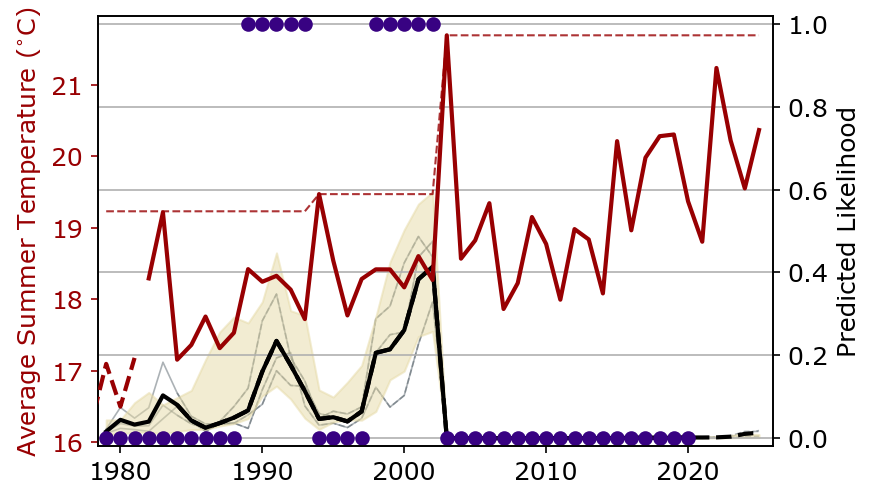

In [279]:
fig, ax2 = plt.subplots(figsize=(6,3.5))
# fig, ax2 = plt.subplots(figsize=(10,3.5))

# xvec1 = np.arange(1989,2026)
# xvec2 = np.arange(1992,2026)
# xvec2a = np.arange(1980,1993)

xvec1 = np.arange(experiment_era_obs[0]+9,2026)
xvec2 = np.arange(experiment_era_obs[0]+9+3,2026)
xvec2a = np.arange(experiment_era_obs[0],experiment_era_obs[0]+9+3)

bumpfactor = AllObs.regionalmean-273.15

# Create a twin axis that shares the same x-axis
ax1 = ax2.twinx()
ax2.set_zorder(ax1.get_zorder() + 1)
ax2.patch.set_visible(False) 

plt.grid(axis='y',zorder=-100)

ax2.plot(xvec2a, (AllObs.outputsummer-273.15)[:len(xvec2a)],color='xkcd:blood red',linewidth=2,linestyle='dashed',zorder=5)
ax2.plot(xvec2, (AllObs.outputsummer-273.15)[(len(xvec2a)):],color='xkcd:blood red',linewidth=2,zorder=5,label='summer temperature')
ax2.plot(xvec1,obsinputpriorrecord_t+bumpfactor,linewidth=1,alpha=0.8,color='xkcd:blood red',linestyle='dashed',zorder=5,label='max threshold')
ax2.set_ylabel('Average Summer Temperature ($^{\circ}$C)',color='xkcd:blood red',zorder=5)
ax2.tick_params(axis='y', colors='xkcd:blood red')

# Plot first dataset on the primary y-axis (left)
ax1.plot(xvec1[:-outputavgtime],obspredall.T[:-outputavgtime],color='xkcd:slate grey',linewidth=0.8,alpha=0.5,zorder=1)
ax1.plot(xvec1[:-outputavgtime],np.mean(obspredall,axis=0)[:-outputavgtime],color='black',linewidth=2, label='average CNN',zorder=2)
ax1.plot(xvec1[outputavgtime:],obspredall.T[outputavgtime:],color='xkcd:slate grey',linewidth=0.8,alpha=0.5,zorder=1,linestyle='dashed')
ax1.plot(xvec1[outputavgtime:],np.mean(obspredall,axis=0)[outputavgtime:],color='black',linewidth=2, zorder=2,linestyle='dashed')
plt.fill_between(np.arange(1979,2026),np.min(MPIpredavg,axis=0),np.max(MPIpredavg,axis=0),color='xkcd:beige',alpha=0.5,label='MPI large ensemble range')
ax1.scatter(xvec1[:-outputavgtime],obsoutput,color="xkcd:indigo",label='event class',zorder=3)
ax1.set_xlabel('Year')
ax1.set_ylabel('Predicted Likelihood')
ax1.set_ylim(-0.02,1.02)

ax1.set_xlim(1978.4,2026)

# handles1, labels1 = ax1.get_legend_handles_labels()
# handles2, labels2 = ax2.get_legend_handles_labels()

# handles = handles2 + handles1
# labels = labels2 + labels1

# # 2. Place the legend completely outside the plot to the right
# ax1.legend(
#     handles, 
#     labels, 
#     loc='upper left', 
#     bbox_to_anchor=(1.15, 1.0),  # Adjust 1.15 (x-position) to push further right/left
#     frameon=True
# )
plt.tight_layout()
plt.savefig("figs/timeseries_"+str(latsel)+"_"+str(lonsel)+"recordmax.png",bbox_inches='tight', dpi=300)
# plt.show()


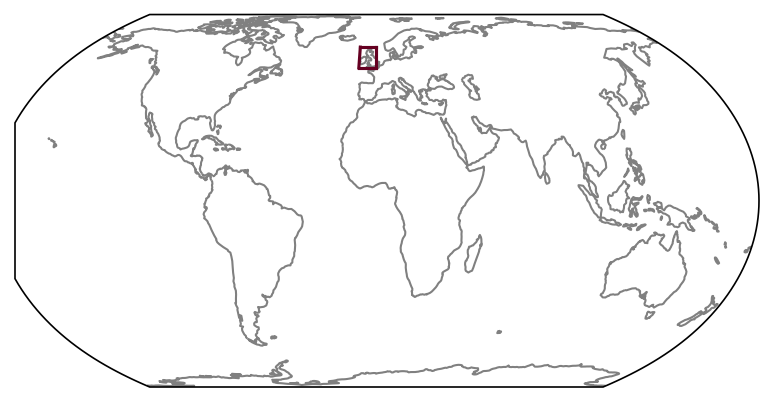

In [280]:
loncoords_NA = [245,255,265]
loncoords_NE = [355,5,15]

latcoords_NA = [45,45,45]
latcoords_NE = [45,45,45]

loncoords_NE = [-5]

latcoords_NE = [55]

mapemtpy = np.ones((18,36))+np.nan

ax=plt.subplot(1,1,1,projection=ccrs.EqualEarth())
ax.pcolormesh(lonvec+5,latvec+5,mapemtpy,transform=ccrs.PlateCarree())
ax.coastlines(color='gray',zorder=0)

# ax.scatter(loncoords_NA,latcoords_NA,marker='o',color='xkcd:royal blue',transform=ccrs.PlateCarree(),zorder=1)
# ax.scatter(loncoords_NE,latcoords_NE,marker='o',color='xkcd:maroon',transform=ccrs.PlateCarree(),zorder=2)
ax.plot([loncoords_NE[0]-5,loncoords_NE[0]+5],[latcoords_NE[0]-5,latcoords_NE[0]-5],transform=ccrs.PlateCarree(),color='xkcd:maroon')
ax.plot([loncoords_NE[0]-5,loncoords_NE[0]+5],[latcoords_NE[0]+5,latcoords_NE[0]+5],transform=ccrs.PlateCarree(),color='xkcd:maroon')
ax.plot([loncoords_NE[0]-5,loncoords_NE[0]-5],[latcoords_NE[0]-5,latcoords_NE[0]+5],transform=ccrs.PlateCarree(),color='xkcd:maroon')
ax.plot([loncoords_NE[0]+5,loncoords_NE[0]+5],[latcoords_NE[0]-5,latcoords_NE[0]+5],transform=ccrs.PlateCarree(),color='xkcd:maroon')



In [281]:
xvec2_ex_scatter = xvec2[(AllObs.outputsummer-273.15)[(len(xvec2a)):]>(obsinputpriorrecord_t.numpy()+bumpfactor)[0]]

ex_scattre = (AllObs.outputsummer-273.15)[(len(xvec2a)):][(AllObs.outputsummer-273.15)[(len(xvec2a)):]>(obsinputpriorrecord_t.numpy()+bumpfactor)[0]]

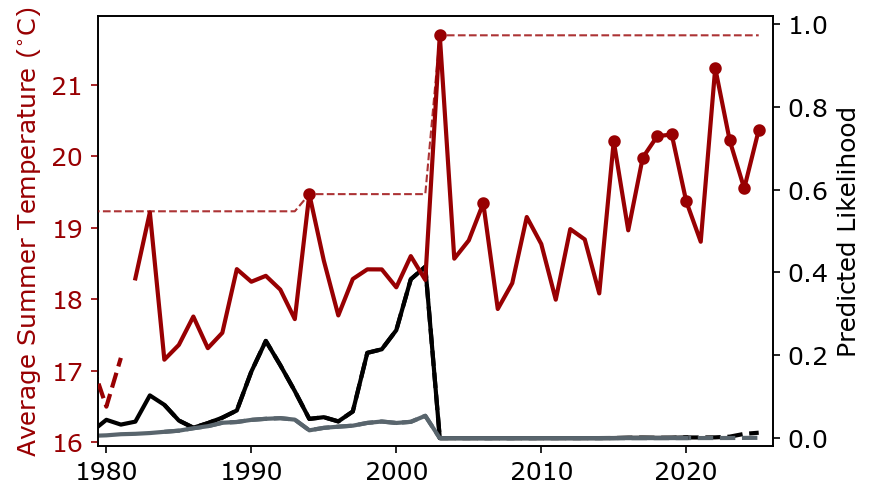

In [282]:
fig, ax2 = plt.subplots(figsize=(6,3.5))
# fig, ax2 = plt.subplots(figsize=(10,3.5))

# xvec1 = np.arange(1989,2026)
# xvec2 = np.arange(1992,2026)
# xvec2a = np.arange(1980,1993)

xvec1 = np.arange(experiment_era_obs[0]+9,2026)
xvec2 = np.arange(experiment_era_obs[0]+9+3,2026)
xvec2a = np.arange(experiment_era_obs[0],experiment_era_obs[0]+9+3)

bumpfactor = AllObs.regionalmean-273.15

# Create a twin axis that shares the same x-axis
ax1 = ax2.twinx()
ax2.set_zorder(ax1.get_zorder() + 1)
ax2.patch.set_visible(False) 

# plt.grid(axis='y',zorder=-100)

ax2.plot(xvec2a, (AllObs.outputsummer-273.15)[:len(xvec2a)],color='xkcd:blood red',linewidth=2,linestyle='dashed',zorder=5)
ax2.plot(xvec2, (AllObs.outputsummer-273.15)[(len(xvec2a)):],color='xkcd:blood red',linewidth=2,zorder=5,label='summer temperature')
ax2.plot(xvec1,obsinputpriorrecord_t+bumpfactor,linewidth=1,alpha=0.8,color='xkcd:blood red',linestyle='dashed',zorder=5,label='max threshold')
ax2.scatter(xvec2_ex_scatter,ex_scattre,color='xkcd:blood red',marker='.',linewidth=3)
ax2.set_ylabel('Average Summer Temperature ($^{\circ}$C)',color='xkcd:blood red',zorder=5)
ax2.tick_params(axis='y', colors='xkcd:blood red')

# Plot first dataset on the primary y-axis (left)
# ax1.plot(xvec1[:-outputavgtime],obspredall.T[:-outputavgtime],color='xkcd:slate grey',linewidth=0.8,alpha=0.5,zorder=1)
ax1.plot(xvec1[outputavgtime:],np.mean(obspredall,axis=0)[outputavgtime:],color='black',linewidth=2, zorder=2,linestyle='dashed')
ax1.plot(xvec1[outputavgtime:],np.mean(obspredclimo,axis=0)[outputavgtime:],linewidth=2, label='average CNN',zorder=2,linestyle='dashed',color='xkcd:slate grey')
ax1.plot(xvec1[:-outputavgtime],np.mean(obspredall,axis=0)[:-outputavgtime],color='black',linewidth=2, label='average CNN',zorder=2)
ax1.plot(xvec1[:-outputavgtime],np.mean(obspredclimo,axis=0)[:-outputavgtime],linewidth=2, label='average CNN',zorder=2,color='xkcd:slate grey')
# ax1.plot(xvec1[outputavgtime:],obspredall.T[outputavgtime:],color='xkcd:slate grey',linewidth=0.8,alpha=0.5,zorder=1,linestyle='dashed')

# plt.fill_between(np.arange(1979,2026),np.min(MPIpredavg,axis=0),np.max(MPIpredavg,axis=0),color='xkcd:beige',alpha=0.5,label='MPI large ensemble range')
# ax1.scatter(xvec1[:-outputavgtime],obsoutput,color="xkcd:indigo",label='event class',zorder=3)
# ax1.set_xlabel('Year')
ax1.set_ylabel('Predicted Likelihood')
ax1.set_ylim(-0.02,1.02)

ax1.set_xlim(1979.4,2026)

# handles1, labels1 = ax1.get_legend_handles_labels()
# handles2, labels2 = ax2.get_legend_handles_labels()

# handles = handles2 + handles1
# labels = labels2 + labels1

# # 2. Place the legend completely outside the plot to the right
# ax1.legend(
#     handles, 
#     labels, 
#     loc='upper left', 
#     bbox_to_anchor=(1.15, 1.0),  # Adjust 1.15 (x-position) to push further right/left
#     frameon=True
# )
plt.tight_layout()
# plt.savefig("figs/timeseries_"+str(latsel)+"_"+str(lonsel)+"recordmax.png",bbox_inches='tight', dpi=300)
# plt.show()


In [283]:
# lon1 = np.arange(2,362,4)
# lat1 = np.arange(-88,92,4)

# for i in range(10):

#     ax=plt.subplot(1,1,1,projection=ccrs.PlateCarree())
#     ax.pcolormesh(lon1,lat1,obsinput_climo_t[0,i].numpy(),cmap='RdBu_r',vmin=-0.5,vmax=0.5)
#     ax.coastlines(color='gray')
#     plt.show()

In [284]:
predsoutfile = "predictions/MPI_recordtemp_avgtime_"+str(outputavgtime)+"_obs_lat_"+str(latsel)+"_perturbGMT.pkl"
with open(predsoutfile,'rb') as f:

    allperturb = pickle.load(f)

perturbs = allperturb[0][int(lonsel/10)]
climos = allperturb[1][int(lonsel/10)]

In [285]:
np.mean(perturbs,axis=0).shape

(60, 47)

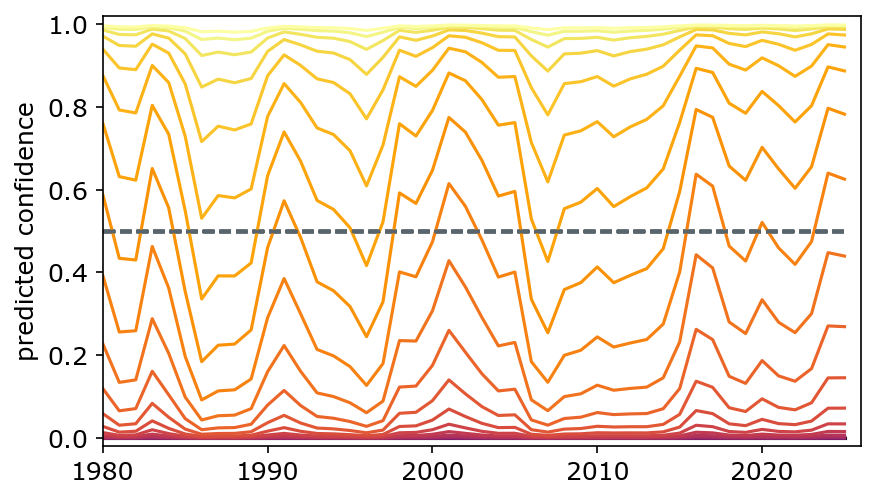

In [286]:
fig, ax2 = plt.subplots(figsize=(6,3.5))

colors = plt.cm.inferno(np.linspace(0, 1, 30))

for iplot in range(30):
    plt.plot(xvec1,np.mean(perturbs,axis=0).T[:,2*iplot],color=colors[iplot])
    plt.ylabel('predicted confidence')
    plt.hlines(0.5,1980,2025,color='xkcd:slate gray',linestyle='dashed')

# plt.plot(xvec1,np.mean(perturbs,axis=0).T[:,32],color=colors[iplot+1])

plt.xlim(1980,2026)
plt.ylim(-0.02,1.02)

plt.tight_layout()

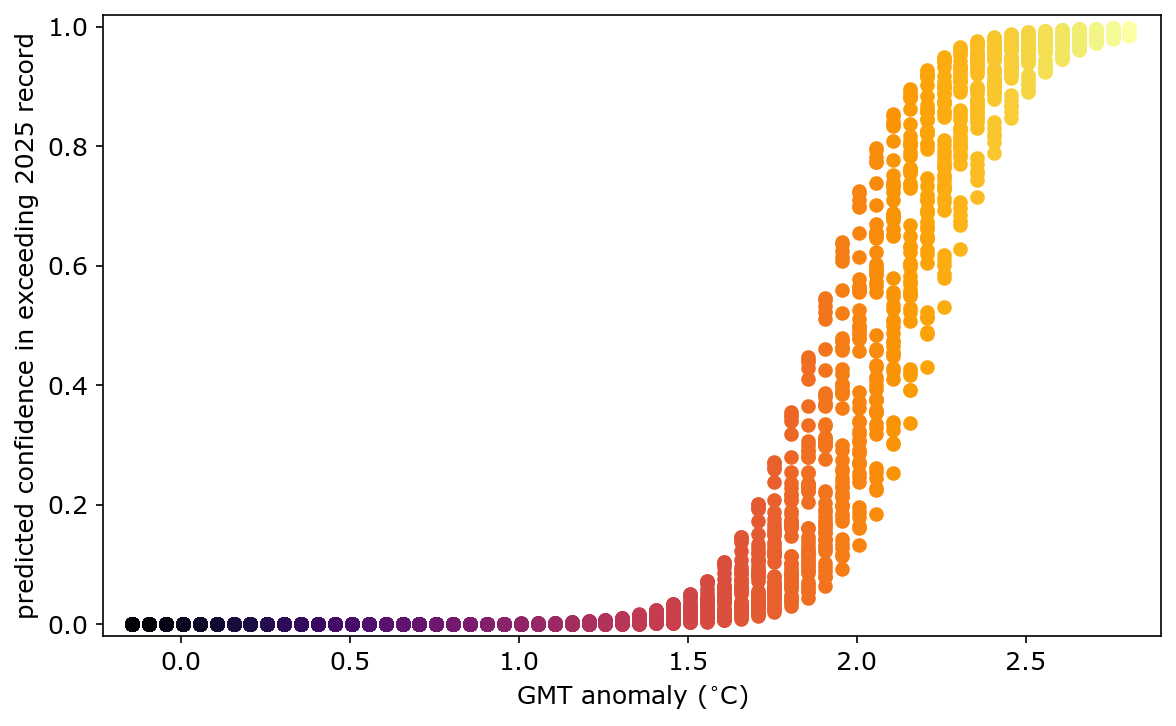

In [287]:
fig, ax2 = plt.subplots(figsize=(8,5))

gmtvec = np.arange(-0.5,2.5,0.05)+0.35668
colors = plt.cm.inferno(np.linspace(0, 1, 61))

scattervec = np.ones(xvec1.shape)
colors = plt.cm.inferno(np.linspace(0, 1, 60))

for iplot in range(len(gmtvec)):

    xplot = scattervec*gmtvec[iplot]

    plt.scatter(xplot,np.mean(perturbs,axis=0)[iplot],color=colors[iplot])
    
    plt.ylabel('predicted confidence in exceeding 2025 record')
    # plt.hlines(0.5,-0.23,2.9,color='xkcd:slate gray',linestyle='dashed')

# plt.plot(gmtvec,np.mean(climos,axis=0),color='xkcd:forest green',linewidth=2)
# cbar=plt.colorbar()
# cbar.ax.set_ylabel('GMT anomaly')
# plt.plot(xvec1,np.mean(perturbs,axis=0).T[:,32],color=colors[iplot+1])

plt.xlabel('GMT anomaly ($^{\circ}$C)')
plt.xlim(-0.23,2.9)
plt.ylim(-0.02,1.02)

plt.tight_layout()